**Вариант 10. Комплексный EDA с мини-дашбордом**

## Финальный проект: комплексный анализ датасета `tips`

### Цель проекта

Провести исследовательский анализ данных, оценить их качество, создать дополнительные метрики, изучить категории, распределения и взаимосвязи между признаками, подготовить графики для презентации результатов, а также сделать выводы на основе полученных результатов.



---

## **Задание 1. Загрузка и описание данных**

Необходимо:

1. Импортировать:
   - `pandas`;
   - `seaborn`;
   - `matplotlib.pyplot`.
2. Загрузить датасет `tips`.
3. Вывести первые строки.
4. Вывести `info()`.
5. Вывести размер таблицы и список столбцов.
6. Описать каждую переменную.

## **Решение задания 1. Загрузка и описание данных**


1. Импортированы:
   - `pandas`;
   - `seaborn`;
   - `matplotlib.pyplot`.
2. Загружен датасет `tips`.
3. Выведены первые строки.
4. Выведен `info()`.
5. Выведен размер таблицы и список столбцов.
6. Описана каждая переменная.

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from matplotlib import lines
from numpy import ma
import numpy as np


tips = sns.load_dataset('tips')
tips.to_csv('tips.csv', index=False)

In [3]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [ ]:
tips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [ ]:
tips.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [ ]:
tips.shape

(244, 7)

In [ ]:
tips.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')

In [ ]:
round(tips['total_bill'].median(), 2)

17.8

***Из полученных данных можно сделать следующие выводы:***

Датасет `tips` содержит 244 наблюдения и 7 признаков. Каждая строка соответствует одному заказу в ресторане.


Признаки датасета:

*   категориальные:

    `sex` - пол клиента;

    `smoker` - курящий клиент или нет;

    `day` - день недели;

    `time` -время посещения;
*   числовые:

    `total_bill`;

    `tip`;

    `size`.





**Данные готовы к исследовательскому анализу (EDA).**




Данные подходят и уже готовы к первичному исследовательскому анализу и не требуют обработки пропусков.

Также посмотрим на квартили:
у 50% заказов сумма счета находится примерно в диапазоне от 13 до 24 долларов. Это говорит о том, что большинство счетов сосредоточено в относительно узком интервале, несмотря на наличие более дорогих заказов.

Значения среднего и медианного счета:

mean = 19.79

median = 17.80


> Разница около 2 долларов. Это не очень большая разница. Она говорит скорее о том, что распределение слегка вправо, т.е. есть некоторое количество дорогих счетов, которые делают среднее чуть выше.




---

##**Решение задания 2. Проверка качества данных**

1. Проверены пропуски.
2. Проверены дубликаты.
3. Проверены уникальные значения категориальных признаков.
4. Посчитаны количество наблюдений по `day`, `time`, `size`.
5. Результат проверки (требуется ли очистка) - очистка данных не требуется.

Вместо unique() я выбрала value_counts(),

так как он показывает не только категории, но и их частоту.

In [ ]:
gaps = tips.isna().sum()

dup = tips.duplicated().sum()
dup_percent = (dup / tips.shape[0]) * 100

categorical_columns = ['sex', 'smoker', 'day', 'time']

def unique_categ():
  for col in categorical_columns:
    print(f'Признак: {tips[col].value_counts()}')
    print('**')

count_day = tips['day'].value_counts()
count_time = tips['time'].value_counts()
count_size = tips['size'].value_counts()


print('Количество пропусков:')
print(gaps)
print('---'*10)
print('\nКоличество дубликатов:')
print(dup)
print(f'\nДубликаты: \n{tips[tips.duplicated(keep=False)]}' )
print(f'\nДоля дубликатов: {dup_percent:.1f}%')
print('---'*10)
print('\nУникальные значения категориальных признаков:')
unique_categ()
print('---'*10)
print('\nКоличество заказов по дням:')
print(count_day)
print('**')
print('Количество заказов по времени:')
print(count_time)
print('**')
print('Размер компаний:')
print(count_size)

Количество пропусков:
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64
------------------------------

Количество дубликатов:
1

Дубликаты: 
     total_bill  tip     sex smoker   day   time  size
198        13.0  2.0  Female    Yes  Thur  Lunch     2
202        13.0  2.0  Female    Yes  Thur  Lunch     2

Доля дубликатов: 0.4%
------------------------------

Уникальные значения категориальных признаков:
Признак: sex
Male      157
Female     87
Name: count, dtype: int64
**
Признак: smoker
No     151
Yes     93
Name: count, dtype: int64
**
Признак: day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64
**
Признак: time
Dinner    176
Lunch      68
Name: count, dtype: int64
**
------------------------------

Количество заказов по дням:
day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64
**
Количество заказов по времени:
time
Dinner    176
Lunch      68
Name: count, dtype: in

In [ ]:
categorical_columns = ['sex', 'smoker', 'day', 'time']

def unique_categ():
  for col in categorical_columns:
    print(f'Признак: {tips[col].value_counts()}')
    print()
print('\nУникальные значения категориальных признаков:')
unique_categ()



Уникальные значения категориальных признаков:
Признак: sex
Male      157
Female     87
Name: count, dtype: int64

Признак: smoker
No     151
Yes     93
Name: count, dtype: int64

Признак: day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

Признак: time
Dinner    176
Lunch      68
Name: count, dtype: int64




***Требуется ли нам очистка данных:***

В ходе проверки обнаружен один полный дубликат.
Поскольку в датасете отсутствуют уникальные идентификаторы заказов и точное время совершения транзакции, нельзя однозначно утверждать,

что данная запись является ошибочной. Она может соответствовать
реальному заказу с идентичными характеристиками. Доля дубликатов составляет
около 0,4% от общего объема данных, поэтому

**принято решение сохранить запись в выборке**.


> Очистка данных не требуется.

##**Решение задания 3. Feature engineering**

Создайте дополнительные признаки:

```python
tips['tip_percent'] = tips['tip'] / tips['total_bill'] * 100
tips['bill_per_person'] = tips['total_bill'] / tips['size']
tips['tip_per_person'] = tips['tip'] / tips['size']
```

Необходимо:

1. Созданы новые признаки.
2. Выведены первые строки.
3. Получена статистика по новым признакам.
4. Краткий вывод (объяснение каждой метрики).

3.3. Получили статистику по новым признакам

In [ ]:
tips['tip_percent'] = tips['tip'] / tips['total_bill'] * 100
tips['bill_per_person'] = tips['total_bill'] / tips['size']
tips['tip_per_person'] = tips['tip'] / tips['size']

In [ ]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size,tip_percent,bill_per_person,tip_per_person
0,16.99,1.01,Female,No,Sun,Dinner,2,5.944673,8.495000,0.505000
1,10.34,1.66,Male,No,Sun,Dinner,3,16.054159,3.446667,0.553333
2,21.01,3.50,Male,No,Sun,Dinner,3,16.658734,7.003333,1.166667
3,23.68,3.31,Male,No,Sun,Dinner,2,13.978041,11.840000,1.655000
4,24.59,3.61,Female,No,Sun,Dinner,4,14.680765,6.147500,0.902500


In [ ]:
tips[['tip_percent','bill_per_person', 'tip_per_person']].describe()

,tip_percent,bill_per_person,tip_per_person
count,244.000000,244.00000,244.000000
mean,16.080258,7.88823,1.212762
std,6.107220,2.91435,0.491705
min,3.563814,2.87500,0.400000
25%,12.912736,5.80250,0.862500
50%,15.476977,7.25500,1.107500
75%,19.147549,9.39000,1.500000
max,71.034483,20.27500,3.333333


***Краткие выводы по новым метрикам:***

Нами были созданы три новых признака, позволяющих более детально анализировать поведение клиентов:

 - tip_percent показывает относительный размер чаевых;
 - bill_per_person позволяет сравнивать расходы клиентов независимо от размера компании;
 - tip_per_person показывает средний вклад одного посетителя в общую сумму чаевых.

Новые признаки позволят провести более глубокий анализ различий между группами клиентов.

##**Решение задания 4. Описательная статистика и распределения**
1. Получен `describe()` по числовым признакам.
2. Найдено средние и медианные значения.
3. Построены гистограммы:
   - `total_bill`;
   - `tip`;
   - `tip_percent`;
   - `bill_per_person`.
4. Построен boxplot для `total_bill`, `tip`, `tip_percent`.
5. Краткий вывод о распределениях и выбросах.

In [ ]:
tips[['total_bill', 'tip', 'tip_percent', 'bill_per_person']].describe()

,total_bill,tip,tip_percent,bill_per_person
count,244.000000,244.000000,244.000000,244.00000
mean,19.785943,2.998279,16.080258,7.88823
std,8.902412,1.383638,6.107220,2.91435
min,3.070000,1.000000,3.563814,2.87500
25%,13.347500,2.000000,12.912736,5.80250
50%,17.795000,2.900000,15.476977,7.25500
75%,24.127500,3.562500,19.147549,9.39000
max,50.810000,10.000000,71.034483,20.27500


In [ ]:
stats = tips[['total_bill', 'tip', 'tip_percent', 'bill_per_person']].agg(['mean', 'median'])

stats

,total_bill,tip,tip_percent,bill_per_person
mean,19.785943,2.998279,16.080258,7.88823
median,17.795000,2.900000,15.476977,7.25500


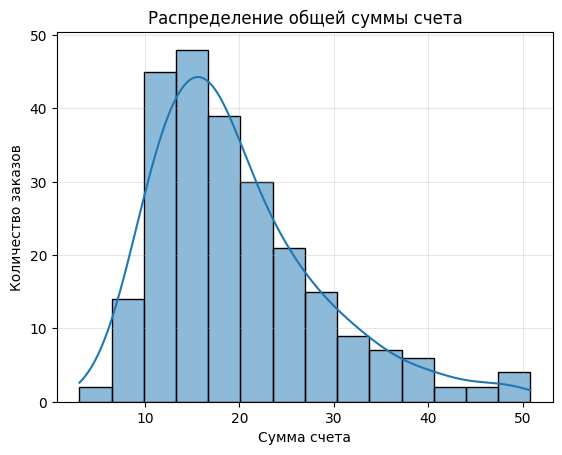

In [ ]:
sns.histplot(
    data=tips,
    x='total_bill',
    kde=True,
    edgecolor='black'
)

plt.title('Распределение общей суммы счета')
plt.xlabel('Сумма счета')
plt.ylabel('Количество заказов')
plt.grid(alpha=0.3)
plt.show()

Построенная ***гистограмма "total_bill"*** показывает нам, что большинство заказов приходится на диапазон 10–25 долларов.

Крупные чеки встречаются редко, поэтому распределение имеет правостороннюю асимметрию.

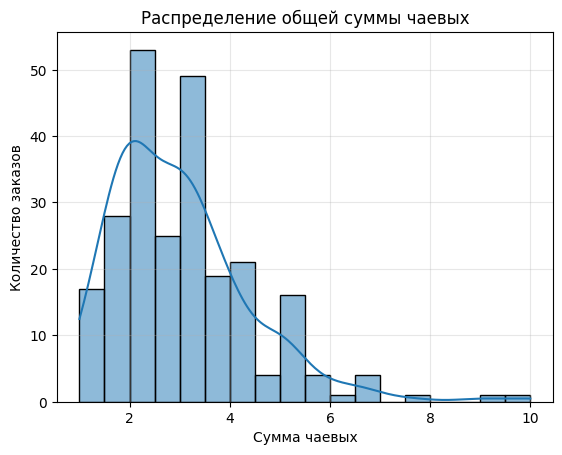

In [ ]:
sns.histplot(
    data=tips,
    x='tip',
    kde=True,
    edgecolor='black'
)

plt.title('Распределение общей суммы чаевых')
plt.xlabel('Сумма чаевых')
plt.ylabel('Количество заказов')
plt.grid(alpha=0.3)
plt.show()

Построенная ***гистограмма "tip"*** показывает нам, что большинство чаевых находится в диапазоне от 2 до 4 долларов. Более крупные суммы чаевых встречаются гораздо реже. Распределение имеет правостороннюю асимметрию, поскольку небольшие чаевые встречаются чаще, а большие суммы являются единичными случаями.

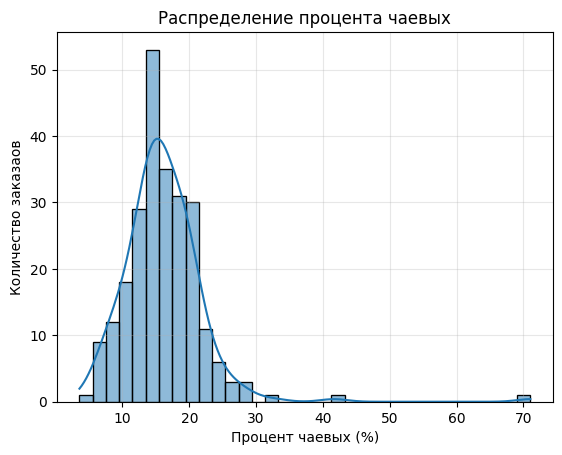

In [ ]:
sns.histplot(
    data=tips,
    x='tip_percent',
    kde=True,
    edgecolor='black'
)

plt.title('Распределение процента чаевых')
plt.xlabel('Процент чаевых (%)')
plt.ylabel('Количество заказаов')
plt.grid(alpha=0.3)
plt.show()

Построенная ***гистограмма "tip_percent"*** показывает нам, что большинство клиентов оставляют чаевые в диапазоне около 15–20% от суммы счета. Встречаются отдельные случаи с более высоким процентом чаевых, что приводит к наличию правого "хвоста" распределения.

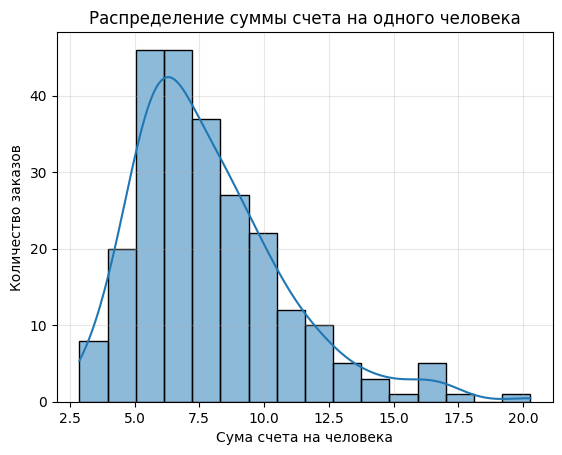

In [ ]:
sns.histplot(
    data=tips,
    x='bill_per_person',
    kde=True,
    edgecolor='black'
)

plt.title('Распределение суммы счета на одного человека')
plt.xlabel('Сума счета на человека')
plt.ylabel('Количество заказов')
plt.grid(alpha=0.3)
plt.show()

Построенная ***гистограмма "bill_per_person"*** показывает нам, что большинство значений суммы счета на одного человека находится в диапазоне примерно 5-10 долларов. Более высокие значения встречаются значительно реже. Распределение имеет небольшую правостороннюю асимметрию из-за отдельных заказов с высокой суммой на одного посетителя.

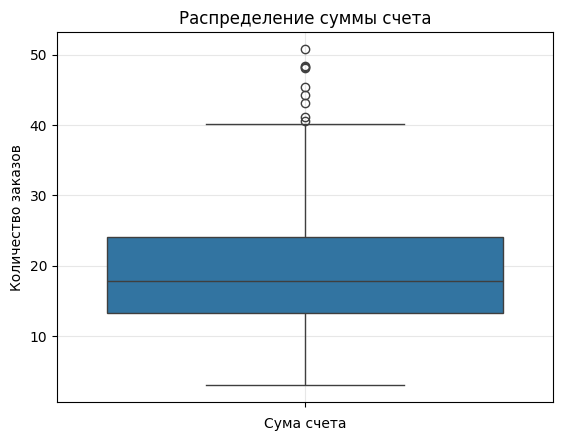

In [ ]:
sns.boxplot(
    data=tips,
    y='total_bill'
)

plt.title('Распределение суммы счета')
plt.xlabel('Сума счета')
plt.ylabel('Количество заказов')
plt.grid(alpha=0.3)
plt.show()

На построенном графике ***boxplot для `total_bill`*** хорошо видно, что основная часть значений total_bill находится примерно в диапазоне от 10 до 25 долларов и наблюдаются отдельные значения с большими суммами счета, которые можно рассматривать как потенциальные выбросы. Распределение имеет правостороннюю асимметрию - наличие редких крупных заказов.

Boxplot (ящик с усами):

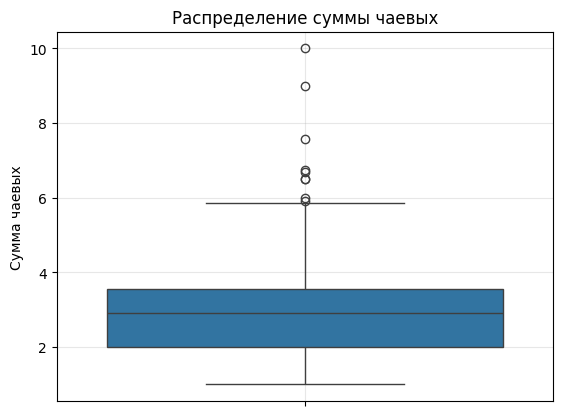

In [ ]:
sns.boxplot(
    data=tips,
    y='tip'
)

plt.title('Распределение суммы чаевых')
plt.ylabel('Сумма чаевых ($)')
plt.grid(alpha=0.3)
plt.show()

На построенном графике ***boxplot для `tip`*** хорошо видно, что основная часть значений tip находится в диапазоне небольших сумм чаевых. На графике присутствуют отдельные значения с высокой суммой чаевых, которые можно рассматривать как потенциальные выбросы. Распределение имеет правостороннюю асимметрию - редкие крупные чаевые.

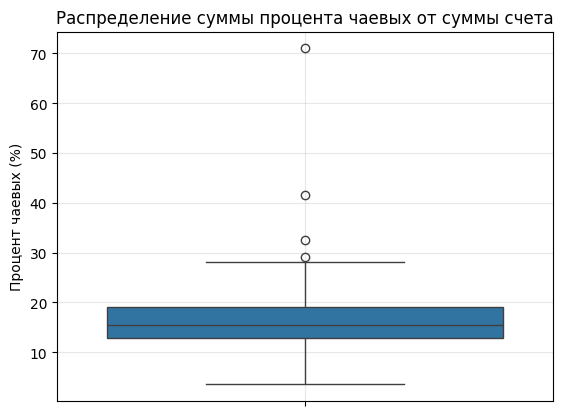

In [ ]:
sns.boxplot(
    data=tips,
    y='tip_percent'
)

plt.title('Распределение суммы процента чаевых от суммы счета')
plt.ylabel('Процент чаевых (%)')
plt.grid(alpha=0.3)
plt.show()

На построенном графике ***boxplot для `tip_percent`*** хорошо видно, что основная часть значений tip_percent находится в диапазоне примерно 15–20%. На графике наблюдаются отдельные значения с высоким процентом чаевых, которые являются потенциальными выбросами. Такие значения могут быть связаны с небольшим размером счета и относительно большой суммой оставленных чаевых.

***Общий вывод о распределениях и выбросах:***

В ходе анализа числовых признаков были изучены распределения общей суммы счета, суммы чаевых, процента чаевых и средней суммы счета на одного человека. Построенные гистограммы показали, что большинство наблюдений сосредоточено в определенных диапазонах значений, а распределения имеют правостороннюю асимметрию, что связано с наличием небольшого количества крупных счетов и высоких чаевых. Boxplot-диаграммы подтвердили наличие отдельных потенциальных выбросов, однако их количество не большое и они не искажают общую картину данных.


> Полученные результаты позволяют перейти к дальнейшему анализу категориальных признаков и взаимосвязей между переменными.


##**Задание 5. Анализ категорий**

Необходимо:

1. Посчитать средние значения `total_bill`, `tip`, `tip_percent` по:
   - `sex`;
   - `smoker`;
   - `day`;
   - `time`;
   - `size`.
2. Построить barplot для среднего `tip` по `day`.
3. Построить barplot для среднего `tip_percent` по `time`.
4. Построить countplot количества заказов по `day`.
5. Сделать вывод.

Вопросы:

- Где больше заказов?
- Где выше средний счет?
- Где выше средний процент чаевых?

5.1. Посчитаем средние значения

Мы можем посчитать отдельно по каждому признаку или пройтись в цикле

Ожидаемый вывод:

In [ ]:
categories = ['sex', 'smoker', 'day', 'time', 'size']

for col in categories:
    print(tips.groupby(col)[['total_bill', 'tip',
                             'tip_percent']].mean().round(2))


        total_bill   tip  tip_percent
sex                                  
Male         20.74  3.09        15.77
Female       18.06  2.83        16.65
        total_bill   tip  tip_percent
smoker                               
Yes          20.76  3.01        16.32
No           19.19  2.99        15.93
      total_bill   tip  tip_percent
day                                
Thur       17.68  2.77        16.13
Fri        17.15  2.73        16.99
Sat        20.44  2.99        15.32
Sun        21.41  3.26        16.69
        total_bill   tip  tip_percent
time                                 
Lunch        17.17  2.73        16.41
Dinner       20.80  3.10        15.95
      total_bill   tip  tip_percent
size                               
1           7.24  1.44        21.73
2          16.45  2.58        16.57
3          23.28  3.39        15.22
4          28.61  4.14        14.59
5          30.07  4.03        14.15
6          34.83  5.22        15.62


/tmp/ipykernel_4827/2896710228.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(tips.groupby(col)[['total_bill', 'tip', 'tip_percent']].mean().round(2))
/tmp/ipykernel_4827/2896710228.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(tips.groupby(col)[['total_bill', 'tip', 'tip_percent']].mean().round(2))
/tmp/ipykernel_4827/2896710228.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(tips.groupb

In [ ]:
tips.groupby('sex', observed=False)[['tip','total_bill', 'tip_percent']].mean().round(2)

,tip,total_bill,tip_percent
sex,,,
Male,3.09,20.74,15.77
Female,2.83,18.06,16.65


In [ ]:
tips.groupby('smoker', observed=False)[['tip','total_bill', 'tip_percent']].mean().round(2)

,tip,total_bill,tip_percent
smoker,,,
Yes,3.01,20.76,16.32
No,2.99,19.19,15.93


In [ ]:
tips.groupby('day', observed=False)[['tip','total_bill', 'tip_percent']].mean().round(2)

,tip,total_bill,tip_percent
day,,,
Thur,2.77,17.68,16.13
Fri,2.73,17.15,16.99
Sat,2.99,20.44,15.32
Sun,3.26,21.41,16.69


In [ ]:
tips.groupby('time', observed=False)[['tip','total_bill', 'tip_percent']].mean().round(2)

,tip,total_bill,tip_percent
time,,,
Lunch,2.73,17.17,16.41
Dinner,3.10,20.80,15.95


In [ ]:
tips.groupby('size', observed=False)[['tip','total_bill', 'tip_percent']].mean().round(2)

,tip,total_bill,tip_percent
size,,,
1,1.44,7.24,21.73
2,2.58,16.45,16.57
3,3.39,23.28,15.22
4,4.14,28.61,14.59
5,4.03,30.07,14.15
6,5.22,34.83,15.62


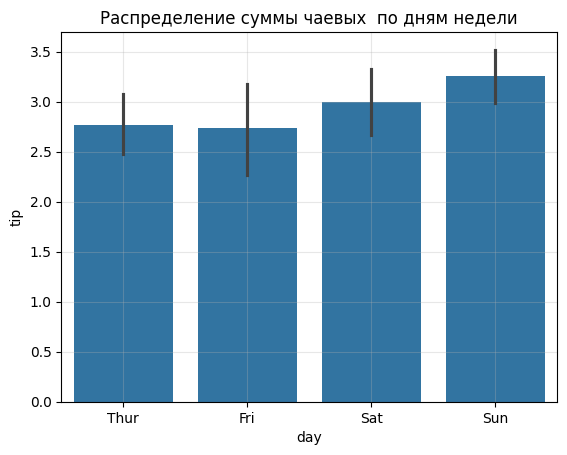

In [ ]:
sns.barplot(data=tips,
            x='day',
            y='tip')
plt.title('Распределение суммы чаевых  по дням недели')
plt.grid(alpha=0.3)
plt.show()

По нашему графику ***barplot для среднего tip по day*** видно, что самые высокие средние чаевые оставляют в воскресенье и субботу. Вероятно, это связано с тем, что в выходные посетители могут проводить в ресторане больше времени, заказывать на большую сумму или приходить компаниями. Однако по данному графику нельзя сделать вывод о количестве посетителей — для этого необходимо проанализировать число заказов по дням недели.

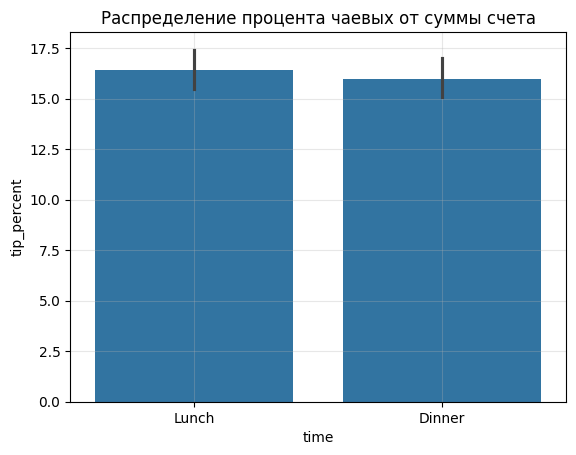

In [ ]:
sns.barplot(data=tips,
            x='time',
            y='tip_percent')
plt.title('Распределение процента чаевых от суммы счета')
plt.grid(alpha=0.3)
plt.show()

По графику ***barplot для среднего `tip_percent` по `time`*** видно, что средний процент чаевых немного выше во время обеда (Lunch) — около 16,5%, тогда как во время ужина (Dinner) он составляет около 15,5%. Разница не большая, однако можно предположить, что посетители во время обеда оставляют несколько больший процент чаевых относительно суммы счета. Мы можем только предположить, с чем связана такая разница - точных данных для такого анализа у нас нет.

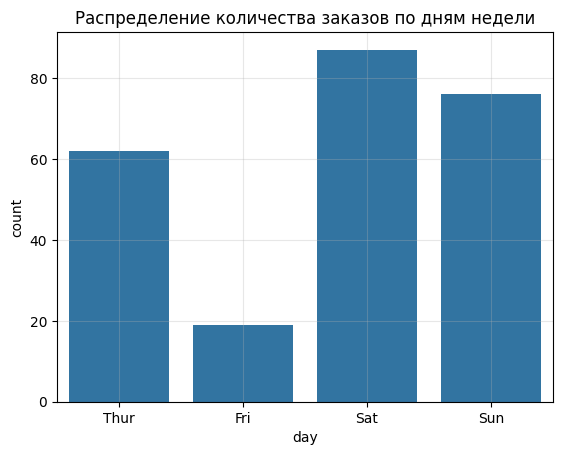

In [ ]:
sns.countplot(data=tips,
            x='day')
plt.title('Распределение количества заказов по дням недели')
plt.grid(alpha=0.3)
plt.show()

По графику видно, что наибольшее количество заказов приходится на субботу и воскресенье, тогда как в пятницу их значительно меньше. Вероятно, это связано с тем, что в выходные дни больше людей посещают ресторан, располагая свободным временем для отдыха и встреч.

5.2.-5.4. Постороение диаграмм

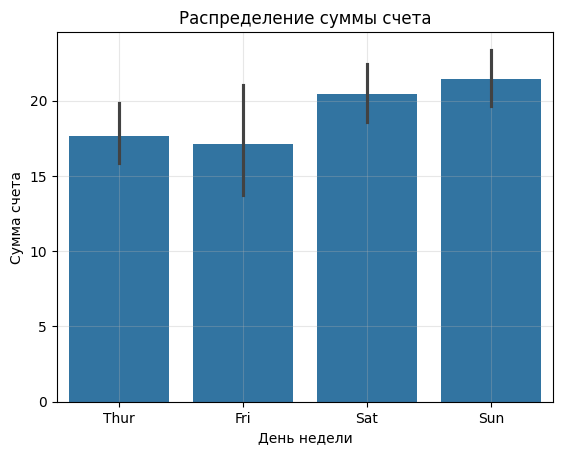

In [ ]:
sns.barplot(data=tips,
            x='day',
            y='total_bill')
plt.title('Распределение суммы счета')
plt.xlabel('День недели')
plt.ylabel('Сумма счета')
plt.grid(alpha=0.3)
plt.show()

По графику видно, что самый высокий средний счет наблюдается в воскресенье, немного ниже — в субботу. Это говорит о том, что в выходные посетители в среднем тратят больше на заказ.

***Общий краткий вывод по анализу категорий:***


> Наибольшее количество заказов приходится на субботу и воскресенье. Минимальное количество заказов наблюдается в пятницу.

> Самый высокий средний счет наблюдается в воскресенье, немного ниже — в субботу. Это говорит о том, что в выходные посетители в среднем тратят больше средств за один заказ.

> Средний процент чаевых немного выше во время обеда (Lunch), чем во время ужина (Dinner). Однако различие невелико и может быть связано с особенностями поведения посетителей в разное время суток.

##**Задание 6. Корреляции и базовые зависимости**

Необходимо:

1. Рассчитать корреляционную матрицу для числовых признаков.
2. Построить heatmap.
3. Построить scatter plot `total_bill` — `tip`.
4. Добавить линию регрессии.
5. Сделать вывод.

Вопросы:

- Какие числовые признаки связаны сильнее всего?
- Как связаны счет и чаевые?
- Есть ли связь между размером компании и чаевыми?

##**Задание 6. Корреляции и базовые зависимости**

1. Рассчитана корреляционная матрица для числовых признаков.
2. Построен heatmap.
3. Построен scatter plot `total_bill` — `tip`.
4. Добавлена линия регрессии.
5. Краткий вывод.


In [ ]:
corr = tips[['total_bill', 'tip', 'tip_percent', 'bill_per_person', 'size']].corr()

corr

,total_bill,tip,tip_percent,bill_per_person,size
total_bill,1.000000,0.675734,-0.338624,0.647497,0.598315
tip,0.675734,1.000000,0.342370,0.347393,0.489299
tip_percent,-0.338624,0.342370,1.000000,-0.314156,-0.142860
bill_per_person,0.647497,0.347393,-0.314156,1.000000,-0.175412
size,0.598315,0.489299,-0.142860,-0.175412,1.000000


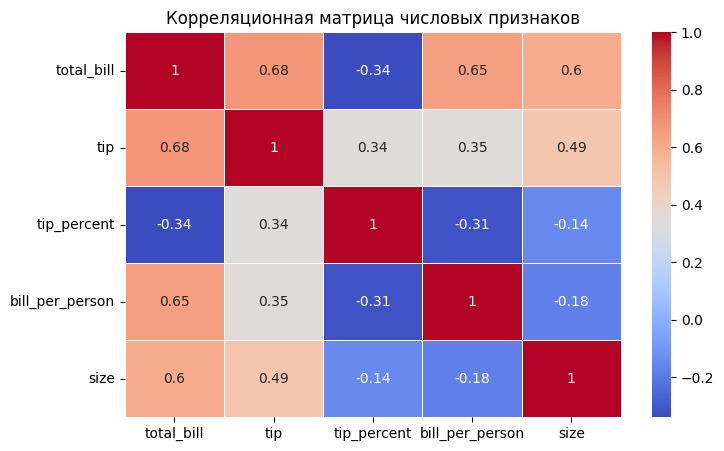

In [ ]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Корреляционная матрица числовых признаков')

plt.show()

***Корреляции и базовые зависимости:***

Корреляционный анализ показал, что наиболее сильная положительная связь наблюдается между суммой счета (total_bill) и размером чаевых (tip) (r = 0.68). Это означает, что с увеличением суммы заказа обычно увеличивается и сумма оставленных чаевых. Также наблюдается положительная связь между размером компании и общей суммой счета (r = 0.60), что объясняется увеличением количества заказов при большем количестве посетителей. Между размером компании и чаевыми существует умеренная положительная связь (r = 0.49), однако она слабее и зависит от других факторов. Процент чаевых (tip_percent) имеет слабую отрицательную связь с размером счета, что может говорить о снижении доли чаевых при крупных заказах.

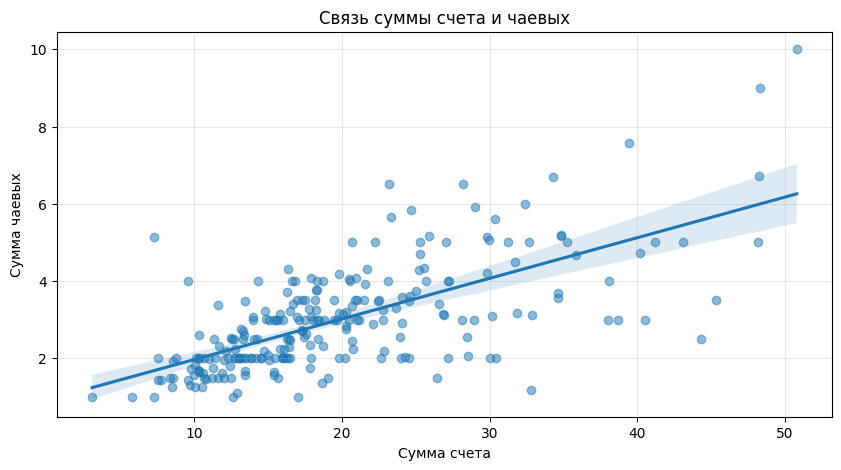

In [ ]:
plt.figure(figsize=(10, 5))

sns.regplot(
    data=tips,
    x='total_bill',
    y='tip',
    scatter_kws={'alpha': 0.5}
)

plt.title('Связь суммы счета и чаевых')
plt.xlabel('Сумма счета')
plt.ylabel('Сумма чаевых')
plt.grid(alpha=0.3)

plt.show()

На диаграмме рассеивания scatter plot `total_bill` — `tip` наблюдается положительная линейная зависимость между суммой счета и размером чаевых. С увеличением суммы заказа размер чаевых также увеличивается. Линия регрессии подтверждает это восходящим трендом, однако наличие разброса точек показывает, что сумма счета не является единственным фактором, влияющим на размер чаевых.

##**Дополнительное задание 7. Комбинированный анализ категорий**

Проведите более сложный анализ сочетаний факторов.

Необходимо:

1. Сравнить `tip` по `day` с разбивкой по `time`.
2. Сравнить `tip_percent` по `sex` с разбивкой по `smoker`.
3. Сравнить `total_bill` по `day` с разбивкой по `smoker`.
4. Построить графики с параметром `hue`.
5. Создать хотя бы одну сводную таблицу по двум категориальным признакам.
6. Сделать вывод.

##**Решение дополнительного задания 7. Комбинированный анализ категорий**

1. Проведено сравнение `tip` по `day` с разбивкой по `time`.
2. Проведено сравнение `tip_percent` по `sex` с разбивкой по `smoker`.
3. Проведено сравнение `total_bill` по `day` с разбивкой по `smoker`.
4. Построены графики с параметром `hue`.
5. Создана сводная таблица по двум категориальным признакам.
6. Краткий вывод.

7.1.-7.4. Графики

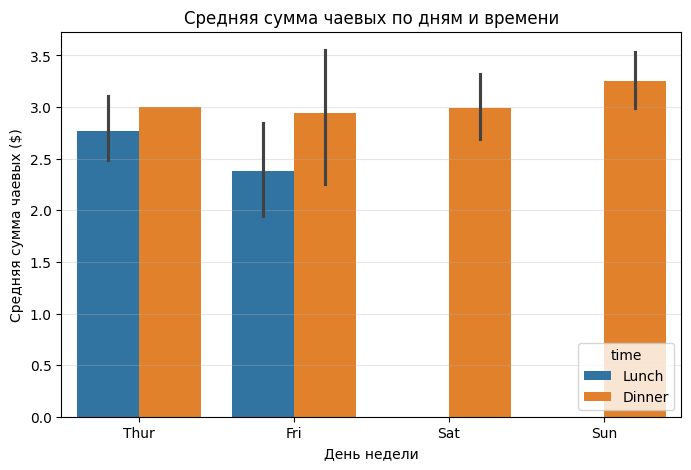

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=tips,
    x='day',
    y='tip',
    hue='time'
)

plt.title('Средняя сумма чаевых по дням и времени')
plt.xlabel('День недели')
plt.ylabel('Средняя сумма чаевых ($)')
plt.grid(axis='y', alpha=0.3)

plt.show()

Анализируя гафик, мы видим, что размер чаевых отличается в зависимости от времени приема пищи. В большинстве дней средняя сумма чаевых выше во время ужина, что может быть связано с более высоким средним счетом в вечернее время.

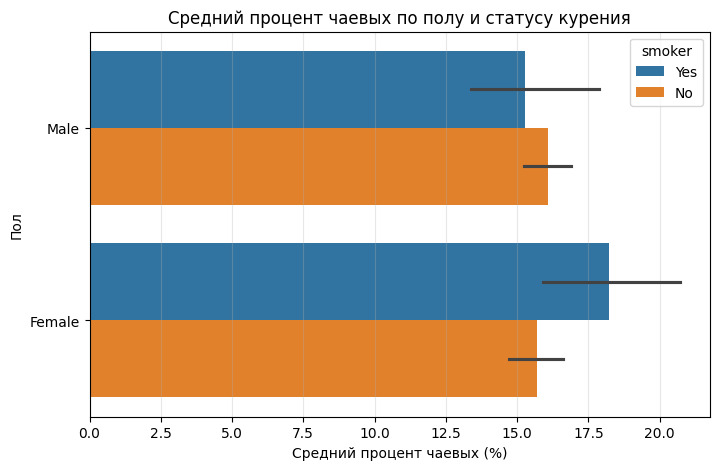

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=tips,
    x='tip_percent',
    y='sex',
    hue='smoker'
)

plt.title('Средний процент чаевых по полу и статусу курения')
plt.xlabel('Средний процент чаевых (%)')
plt.ylabel('Пол')
plt.grid(axis='x', alpha=0.3)

plt.show()

Здесь наш анализ показал, что средний процент чаевых отличается в зависимости от пола и статуса курения. Между группами наблюдаются различия, однако они не являются значительными. На графике видно, что некоторые группы клиентов оставляют немного больший процент чаевых.

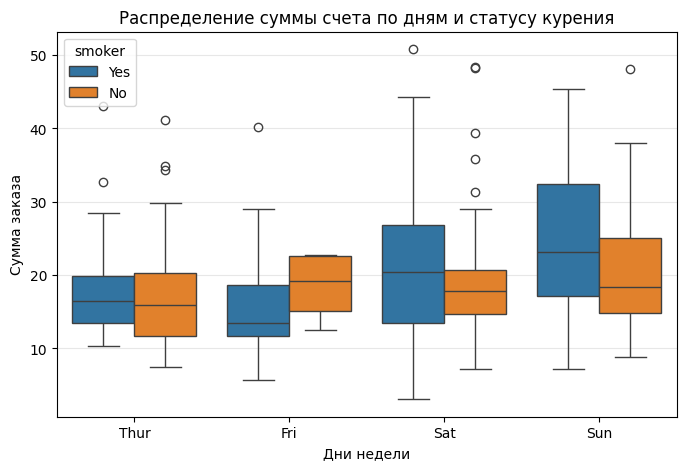

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=tips,
    x='day',
    y='total_bill',
    hue='smoker'
)

plt.title('Распределение суммы счета по дням и статусу курения')
plt.xlabel('Дни недели')
plt.ylabel('Сумма заказа')
plt.grid(axis='y', alpha=0.3)

plt.show()

Наибольшие значения суммы счета наблюдаются в отдельных группах клиентов, однако различия между курящими и некурящими посетителями не выглядят однозначными. На распределение суммы заказа, вероятно, больше влияют другие факторы, например размер компании и время посещения.

In [ ]:
avg_bill_day = tips.pivot_table(index='day', columns='time',
                                values='total_bill',
                                aggfunc='mean', observed=False).round(2)
avg_bill_day

time,Lunch,Dinner
day,,
Thur,17.66,18.78
Fri,12.85,19.66
Sat,NaN,20.44
Sun,NaN,21.41


##***Краткий вывод***

- Сводная таблица показывает, что средняя сумма счета выше в вечернее время.

Наибольшие значения наблюдаются в воскресенье и субботу во время ужина.

Отсутствующие значения для некоторых комбинаций связаны с отсутствием

таких наблюдений в исходном датасете.

- Комбинированный анализ позволил выявить, что наиболее заметное влияние на сумму

счета и чаевые оказывает время посещения и размер заказа, тогда как отдельные

категориальные признаки сами по себе (курящий посетитель или нет)

не всегда объясняют различия в поведении клиентов.

7.5. Сводная таблица по признакам `day` и `time`

Комбинированный анализ позволил выявить, что наиболее заметное влияние на сумму счета и чаевые оказывает время посещения и размер заказа, тогда как отдельные категориальные признаки сами по себе не всегда объясняют различия в поведении клиентов.

####**Общий основной вывод по: комплексный анализ датасета `tips`**

В ходе исследования был проведен комплексный анализ датасета tips.

1. Проверка качества данных показала отсутствие пропусков и наличие лишь одного полного дубликата, который было решено сохранить, поскольку невозможно подтвердить его ошибочность.
2. Были рассчитаны дополнительные показатели, позволившие оценить средний счет и чаевые в расчете на одного человека, а также процент чаевых от суммы заказа.
3. Анализ распределений показал, что большинство заказов имеет относительно небольшую сумму, а распределения характеризуются умеренной правосторонней асимметрией и небольшим количеством потенциальных выбросов.
4. Корреляционный анализ выявил наиболее сильную положительную связь между суммой счета и размером чаевых.
5. Комбинированный анализ показал, что наиболее заметное влияние на сумму счета и чаевые оказывает время посещения, тогда как влияние отдельных категориальных признаков менее выражено.

❗Полученные результаты позволяют сделать вывод, что данные имеют хорошее качество и подходят для дальнейшего анализа поведения клиентов.